Task 1: Import Libraries

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print("Torch versiyasi:", torch.__version__)
print("Torchvision versiyasi:", torchvision.__version__)

Torch versiyasi: 2.11.0+cpu
Torchvision versiyasi: 0.26.0+cpu


Task 2: Load the MNIST Dataset

In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]

Number of training images: 60000
Number of testing images: 10000


Task 3: Explore the Dataset

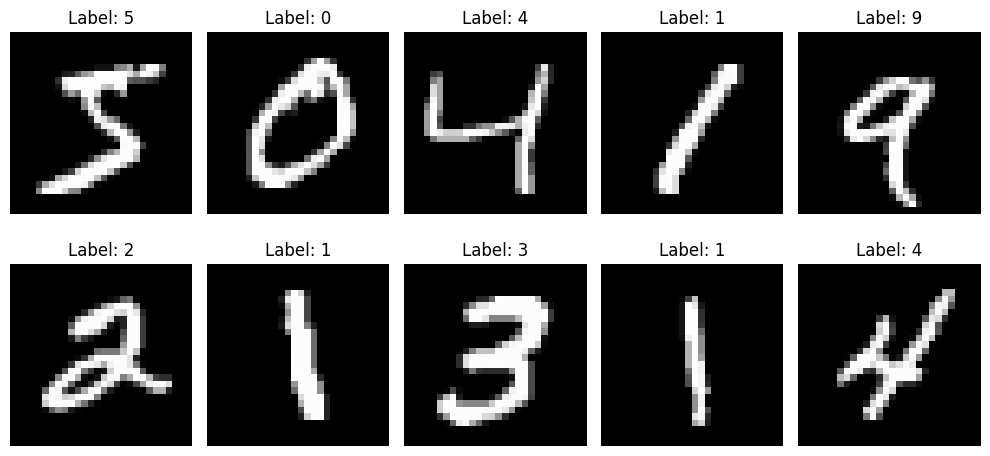

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    image, label = train_dataset[i]
    ax = axes[i // 5, i % 5]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

What do the labels represent?

Yorliqlar (labels) rasmda aks ettirilgan qo'lyozma raqamning mos qiymatini ($0$ dan $9$ gacha bo'lgan son) bildiradi.

How many different classes are there?

Jami $10$ ta sinf (class) mavjud ($0, 1, 2, 3, 4, 5, 6, 7, 8, 9$)

Task 4: Explore Image Properties

In [ ]:
raw_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
raw_image, raw_label = raw_dataset[0]

img_tensor, label = train_dataset[0]

print("Image shape:", img_tensor.shape)
print("Image size:", img_tensor.size())
print("Data type:", img_tensor.dtype)
print("Minimum pixel value:", img_tensor.min().item())
print("Maximum pixel value:", img_tensor.max().item())

Image shape: torch.Size([1, 28, 28])
Image size: torch.Size([1, 28, 28])
Data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


Task 5: Understand Pixel Values

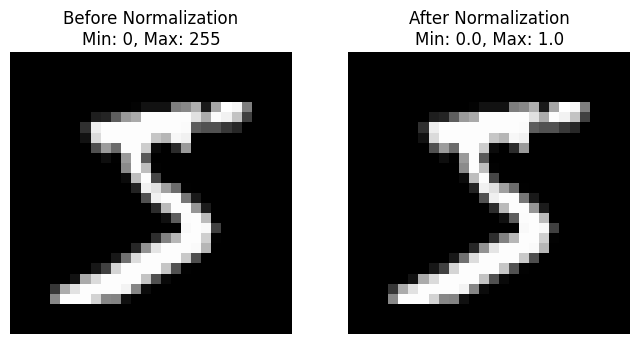

Before normalization -> Min: 0, Max: 255
After normalization  -> Min: 0.0000, Max: 1.0000


In [ ]:
import numpy as np
raw_img_np = np.array(raw_image)

norm_img_np = img_tensor.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(raw_img_np, cmap='gray')
axes[0].set_title(f"Before Normalization\nMin: {raw_img_np.min()}, Max: {raw_img_np.max()}")
axes[0].axis('off')

axes[1].imshow(norm_img_np, cmap='gray')
axes[1].set_title(f"After Normalization\nMin: {norm_img_np.min():.1f}, Max: {norm_img_np.max():.1f}")
axes[1].axis('off')

plt.show()

print(f"Before normalization -> Min: {raw_img_np.min()}, Max: {raw_img_np.max()}")
print(f"After normalization  -> Min: {norm_img_np.min():.4f}, Max: {norm_img_np.max():.4f}")

Why do we normalize images?

Rasmlar piksellarini $0 \dots 255$ oralig'idan $0.0 \dots 1.0$ (yoki $-1.0 \dots 1.0$) oralig'iga o'tkazish uchun.

How does normalization help neural networks?

Normalizatsiya gradientlarning keskin oshib ketishi (exploding gradients) yoki yo'qolib ketishi (vanishing gradients) ning oldini oladi va modelning tezroq hamda barqaror o'rganishiga (gradient descent yaxshi ishlashiga) yordam beradi.

Task 6: Tensor Exploration

In [ ]:
sample_image, sample_label = train_dataset[1]

print("Shape:", sample_image.shape)
print("Data type:", sample_image.dtype)
print("Device:", sample_image.device)
print("Number of dimensions:", sample_image.ndim)

Shape: torch.Size([1, 28, 28])
Data type: torch.float32
Device: cpu
Number of dimensions: 3


Task 7: Image Visualization

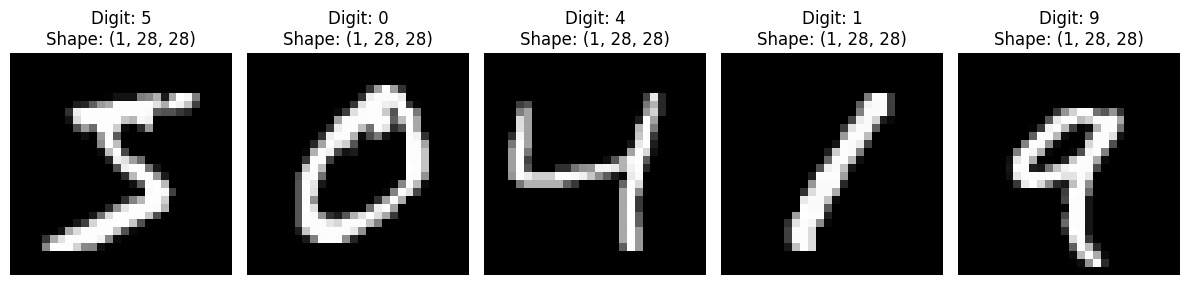

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    img, label = train_dataset[i]
    ax = axes[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Digit: {label}\nShape: {tuple(img.shape)}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Are all images the same size?

Ha, MNIST datasetidagi barcha rasmlar bir xil $28 \times 28$ piksel o'lchamga ega.

Why is having the same image size important for CNNs?

Chunki CNN'ning kirish qatlami va to'liq bog'langan qatlamlari (Dense/Linear layers) qat'iy belgilangan matritsa o'lchamlarini talab qiladi. Agar rasmlar har xil hajmda bo'lsa, og'irliklar (weights) bilan ko'paytirish amallarida xatolik kelib chiqadi.